In [6]:
from tdse_solutions import *
from scipy.optimize import curve_fit

In [7]:
eta_range = np.arange(0.01, 0.051, 0.01)

# Rectangular

In [8]:
npz_archives_rect = [np.load(f'../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-0{k}.npz')
            for k in range(1,4)]

npz_archives_rect_1 = [np.load(f'../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-0{k}.npz')
            for k in range(4,6)]

npz_archives_rect.extend(npz_archives_rect_1)

In [9]:
npz_archives_rect[0].keys()

KeysView(NpzFile '../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-01.npz' with keys: rel_f_range, phase_res_arr, n_loops_arr)

In [10]:
min_inf_arr_rect = []
ph_ex_arr_rect = []

for npz_arch in npz_archives_rect:
    fock0_proj = npz_arch['phase_res_arr']

    min_inf_arr_rect.append([])
    ph_ex_arr_rect.append([])
    for k, n_loops in enumerate(npz_arch['n_loops_arr']):
        inf_range = []
        ph_ex_range = []

        for f0p in fock0_proj[k]:
            inf = 1 - fidelity_from_phase_residuals(f0p)
            ph_ex_range.append(phonon_excitation_prob(f0p))
            inf_range.append(inf)
        min_inf = np.min(inf_range)
        min_k = np.argmin(inf_range)
        ph_ex = ph_ex_range[min_k]
        
        min_inf_arr_rect[-1].append(min_inf)
        ph_ex_arr_rect[-1].append(ph_ex)

min_inf_arr_rect = np.array(min_inf_arr_rect)
ph_ex_arr_rect = np.array(ph_ex_arr_rect)

# Rectangular echoed

In [11]:
npz_archives_rect_sym = [np.load(f'../data/phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-0{k}.npz')
            for k in range(1,6)]


npz_large_limits = np.load(f'../data/phase_res_amplitude_dep_rect_sym_pulse_20_ions_full_ham_eta_0-05_large_limits.npz')

In [12]:
#npz_archives_rect_sym.append(npz_large_limits)

In [13]:
n_loops = 1

In [14]:
min_inf_arr_rect_sym = []
ph_ex_arr_rect_sym = []

for eta, npz_arch in zip(eta_range, npz_archives_rect_sym):
    print(npz_arch['n_loops_arr'])
    min_inf_arr_rect_sym.append([])
    ph_ex_arr_rect_sym.append([])
    for k, n_loops in enumerate(npz_arch['n_loops_arr']):
        if eta == 0.05 and k == 0:
            fock0_proj = npz_large_limits['phase_res_arr']
        else:
            fock0_proj = npz_arch['phase_res_arr']
            
        inf_range = []
        ph_ex_range = []
        for f0p in fock0_proj[k]:
            inf = 1 - fidelity_from_phase_residuals(f0p)
            ph_ex_range.append(phonon_excitation_prob(f0p))
            inf_range.append(inf)
            
        min_inf = np.min(inf_range)
        min_k = np.argmin(inf_range)
        ph_ex = ph_ex_range[min_k]
        
        min_inf_arr_rect_sym[-1].append(min_inf)
        ph_ex_arr_rect_sym[-1].append(ph_ex)

min_inf_arr_rect_sym = np.array(min_inf_arr_rect_sym)
ph_ex_arr_rect_sym   = np.array(ph_ex_arr_rect_sym)            

[1 2 3 6 8]
[1 2 3 6 8]
[1 2 3 6 8]
[1 2 3 6 8]
[1 2 3 6 8]


In [15]:
min_inf_arr_rect_sym

array([[3.79000031e-05, 9.48015915e-06, 4.47822636e-06, 1.77043193e-06,
        8.02520557e-07],
       [5.89055879e-04, 1.50822237e-04, 6.68495542e-05, 1.78827921e-05,
        9.94221103e-06],
       [2.79994610e-03, 7.43644965e-04, 3.35645536e-04, 8.56080852e-05,
        4.89170986e-05],
       [7.86602353e-03, 2.26135321e-03, 1.04378556e-03, 2.69021267e-04,
        1.53400427e-04],
       [1.63245721e-02, 5.18164721e-03, 2.48023316e-03, 6.61823308e-04,
        3.77979549e-04]])

In [16]:
def power_func(x, a, b):
    return a*x**b

In [17]:
#a, b = curve_fit(power_func, eta_range[:-1], min_inf_arr[:-1])[0]

# Lemniscate echoed

In [18]:
npz_archives_lemniscate_sym = [np.load(f'../data/phase_res_2d_dep_lemniscate_sym_20_ions_full_ham_eta_0-0{k}.npz')
            for k in range(1,4)]

npz_archives_lemniscate_sym_1 = [np.load(f'../data/phase_res_2d_dep_lemniscate_sym_20_ions_full_ham_eta_0-0{k}_1.npz')
            for k in range(4,6)]

npz_archives_lemniscate_sym.extend(npz_archives_lemniscate_sym_1)

In [19]:
min_inf_arr_lemniscate_sym = []
ph_ex_arr_lemniscate_sym = []

for npz_arch in npz_archives_lemniscate_sym:
    inf_arr = []
    ph_ex_arr = []
    fock0_proj = npz_arch['phase_res_arr']
    n1, n2 = fock0_proj.shape[0], fock0_proj.shape[1]

    for i, j in itertools.product(range(n1), range(n2)):
        inf = 1 - fidelity_from_phase_residuals(fock0_proj[i,j])
        ph_ex = phonon_excitation_prob(fock0_proj[i,j])
        inf_arr.append(inf)
        ph_ex_arr.append(ph_ex)

    min_inf = np.min(inf_arr)
    min_k = np.argmin(inf_arr)
    ph_ex = ph_ex_arr[min_k]
    min_inf_arr_lemniscate_sym.append(min_inf)
    ph_ex_arr_lemniscate_sym.append(ph_ex)        
    
    # for f0p in fock0_proj[0]:
    #     inf = 1 - fidelity_from_phase_residuals(f0p)
    #     ph_ex_range.append(phonon_excitation_prob(f0p))
    #     inf_range.append(inf)
    # min_inf = np.min(inf_range)
    # min_k = np.argmin(inf_range)
    # ph_ex = ph_ex_range[min_k]
    # min_inf_arr_rect_sym.append(min_inf)
    # ph_ex_arr_rect_sym.append(ph_ex)

In [20]:
eta_range_cut = eta_range[1:]

min_inf_arr_rect_cut = min_inf_arr_rect[1:]
min_inf_arr_rect_sym_cut = min_inf_arr_rect_sym[1:]
min_inf_arr_lemniscate_sym_cut = min_inf_arr_lemniscate_sym[1:]

ph_ex_arr_rect_cut = ph_ex_arr_rect[1:]
ph_ex_arr_rect_sym_cut = ph_ex_arr_rect_sym[1:]
ph_ex_arr_lemniscate_sym_cut = ph_ex_arr_lemniscate_sym[1:]

In [21]:
min_inf_arr_rect.shape

(5, 5)

# Combined plot

In [22]:
def get_tableau_iter():
    return itertools.cycle(matplotlib.colors.TABLEAU_COLORS)

In [23]:
tab_iter = get_tableau_iter()

In [24]:
next(tab_iter)

'tab:blue'

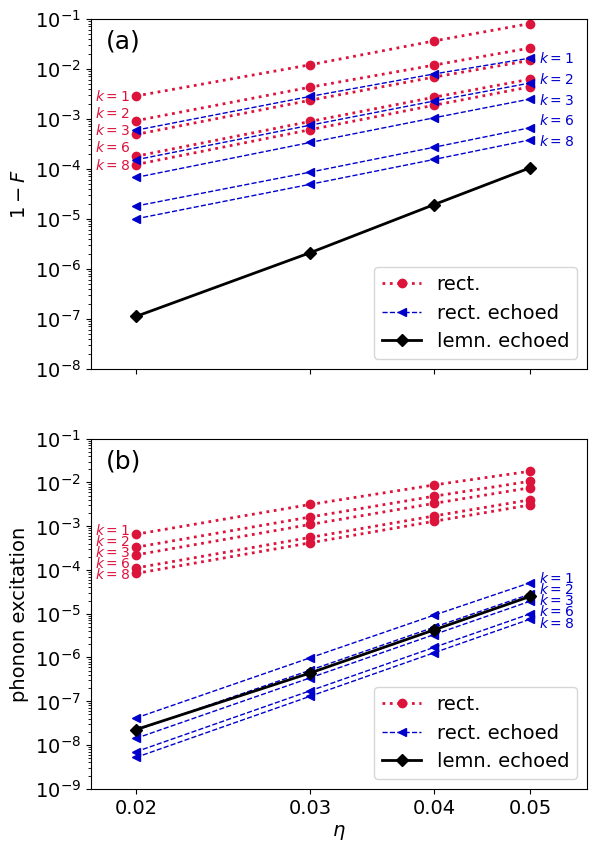

In [99]:
matplotlib.rcParams.update({'font.size' : 14})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.4,10))

n_loops_arr = npz_archives_rect[0]['n_loops_arr']


text_group_1 = []

xmin = 0.018
xmax = 0.057
dxtext1 = 0.0002
dxtext2 = 0.001


for n_loops, inf_range_rect in zip(n_loops_arr, min_inf_arr_rect_cut.T):
    label = 'rect.' if (n_loops == 1) else None
    ax1.plot(eta_range_cut, inf_range_rect, color='crimson', marker='o', linestyle=':', 
             label=label, linewidth=2)#, label=f'rect., k={n_loops}', )
    x = xmin + dxtext1
    i = list(n_loops_arr).index(n_loops)
    y = min_inf_arr_rect_cut[0, 0]*0.8/2.2**i #x**4/eta_range_cut[0]**4*inf_range_rect[0]*1.2
    txt = ax1.text(x, y, f'$k={n_loops}$', color='crimson', fontsize=10)
    text_group_1.append(txt)

text_group_2 = []
for n_loops, inf_range_rect_sym in zip(n_loops_arr, min_inf_arr_rect_sym_cut.T):
    label='rect. echoed' if (n_loops == 1) else None
        
    ax1.plot(eta_range_cut, inf_range_rect_sym, color='mediumblue', marker='<', 
              linestyle='--', linewidth=1, label=label) #label=f'rect. echoed, k={n_loops}')
    x = 0.05 + dxtext2
    i = list(n_loops_arr).index(n_loops)
    y = min_inf_arr_rect_sym_cut[-1, 0]*0.8/2.6**i
    
    txt = ax1.text(x, y, f'$k={n_loops}$', color='mediumblue', fontsize=10)
    text_group_2.append(txt)
    
ax1.plot(eta_range_cut, min_inf_arr_lemniscate_sym_cut, label='lemn. echoed', 
            marker='D', linestyle='-', linewidth=2, color='k')

tab_iter = get_tableau_iter()
for n_loops, ph_ex in zip(n_loops_arr, ph_ex_arr_rect_cut.T):
    label='rect.' if (n_loops == 1) else None
    ax2.plot(eta_range_cut, ph_ex, color='crimson', label=label, marker='o', 
             linestyle=':', linewidth=2)
    x = xmin + dxtext1
    i = list(n_loops_arr).index(n_loops)
    y = ph_ex_arr_rect_cut[0, 0]/1.8**i
    txt = ax2.text(x, y, f'$k={n_loops}$', color='crimson', fontsize=10)

tab_iter = get_tableau_iter()
for n_loops, ph_ex in zip(n_loops_arr, ph_ex_arr_rect_sym_cut.T):
    label='rect. echoed' if (n_loops == 1) else None
    ax2.plot(eta_range_cut, ph_ex, color='mediumblue', label=label, 
             marker='<', linestyle='--', linewidth=1)
    x = 0.05 + dxtext2
    i = list(n_loops_arr).index(n_loops)
    y = ph_ex_arr_rect_sym_cut[-1, 0]/1.8**i
    txt = ax2.text(x, y, f'$k={n_loops}$', color='mediumblue', fontsize=10)
    
ax2.plot(eta_range_cut, ph_ex_arr_lemniscate_sym_cut, label='lemn. echoed', marker='D',
        linestyle='-', linewidth=2, color='k')
#plt.plot(eta_range, 3550*eta_range**4)


for ax in [ax1, ax2]:
    ax.legend(loc='lower right')    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(eta_range_cut)

ax1.set_ylim(1e-8, 1e-1)
ax2.set_ylim(1e-9, 1e-1)
ax1.set_xticklabels(['']*4)
ax2.set_xticklabels(['0.02', '0.03', '0.04', '0.05'])
ax2.set_xlabel(r'$\eta$')

ax1.text(0.03, 0.97, '(a)', verticalalignment='top', transform=ax1.transAxes, fontsize=18)
ax2.text(0.03, 0.97, '(b)', verticalalignment='top', transform=ax2.transAxes, fontsize=18)

ax1.set_ylabel('$1-F$')
ax2.set_ylabel('phonon excitation')

# angle = 15

# for txt in text_group_1:
#     txt.set_rotation(angle)

plt.savefig('../figures/fidelity_eta_deps.pdf')
plt.show()

In [44]:
min_inf_arr_rect.shape

(5, 5)

In [89]:
datafile = np.load(f'../data/phase_res_amplitude_dep_rect_pulse_20_ions_full_ham_eta_0-05.npz')
rel_f_range = datafile['rel_f_range']
fock0_proj = datafile['phase_res_arr']
n_loops_arr = datafile['n_loops_arr']

In [90]:
fock0_proj.shape

(5, 201, 21)

/tmp/ipykernel_14008/3673320364.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


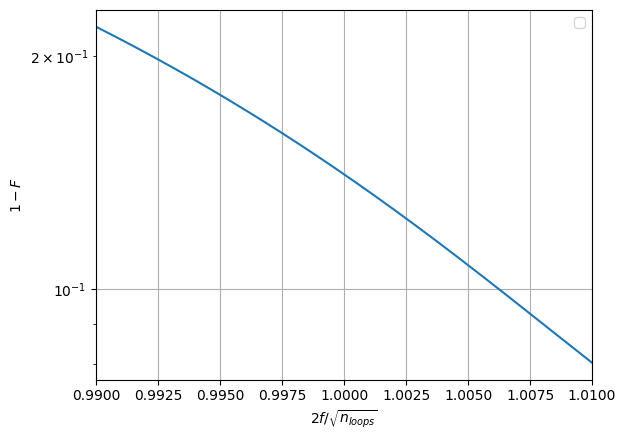

In [91]:
n_ions = 20

inf_range = []
for rel_f, f0p in zip(rel_f_range, fock0_proj[0]):
    inf = 1 - fidelity_from_phase_residuals(f0p)
    inf_range.append(inf)

plt.plot(rel_f_range, inf_range)#, label=f'$n_{{loops}} = {n_loops}$')
    
plt.yscale('log')
plt.margins(x=0)
#plt.title(title)
plt.xlabel('$2f/\sqrt{n_{loops}}$')
plt.ylabel('$1-F$')
plt.legend()
plt.grid()

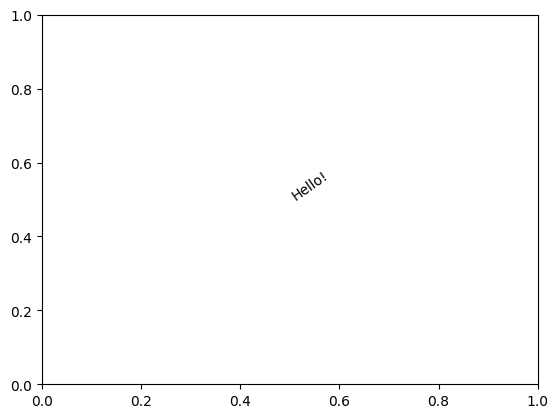

In [4]:
fig, ax = plt.subplots(1,1)
txt = ax.text(0.5, 0.5, 'Hello!', transform=ax.transAxes)
txt.set_rotation(35)

In [2]:
txt.properties()

{'agg_filter': None,
 'alpha': None,
 'animated': False,
 'antialiased': True,
 'bbox_patch': None,
 'children': [],
 'clip_box': <matplotlib.transforms.TransformedBbox at 0x7d080a6c8130>,
 'clip_on': False,
 'clip_path': None,
 'color': 'black',
 'figure': <Figure size 640x480 with 1 Axes>,
 'fontfamily': ['sans-serif'],
 'fontname': 'DejaVu Sans',
 'fontproperties': <matplotlib.font_manager.FontProperties at 0x7d080b81f380>,
 'fontsize': 10.0,
 'fontstyle': 'normal',
 'fontvariant': 'normal',
 'fontweight': 'normal',
 'gid': None,
 'horizontalalignment': 'left',
 'in_layout': True,
 'label': '',
 'math_fontfamily': 'dejavusans',
 'mouseover': False,
 'parse_math': True,
 'path_effects': [],
 'picker': None,
 'position': (0.5, 0.5),
 'rasterized': False,
 'rotation': 0.0,
 'rotation_mode': 'default',
 'sketch_params': None,
 'snap': None,
 'stretch': 'normal',
 'text': 'Hello!',
 'tightbbox': Bbox([[328.0, 234.59999999999997], [368.75, 248.59999999999997]]),
 'transform': <matplotlib.

In [3]:
help(txt)

Help on Text in module matplotlib.text object:

class Text(matplotlib.artist.Artist)
 |  Text(
 |      x=0,
 |      y=0,
 |      text='',
 |      *,
 |      color=None,
 |      verticalalignment='baseline',
 |      horizontalalignment='left',
 |      multialignment=None,
 |      fontproperties=None,
 |      rotation=None,
 |      linespacing=None,
 |      rotation_mode=None,
 |      usetex=None,
 |      wrap=False,
 |      transform_rotates_text=False,
 |      parse_math=None,
 |      antialiased=None,
 |      **kwargs
 |  )
 |
 |  Handle storing and drawing of text in window or data coordinates.
 |
 |  Method resolution order:
 |      Text
 |      matplotlib.artist.Artist
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __getstate__(self)
 |      Helper for pickle.
 |
 |  __init__(
 |      self,
 |      x=0,
 |      y=0,
 |      text='',
 |      *,
 |      color=None,
 |      verticalalignment='baseline',
 |      horizontalalignment='left',
 |      multialignment=None,
 |  